<a href="https://colab.research.google.com/github/cpeng2/GitPractice/blob/main/dec9/data71200dec9lab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Load Libraries

In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
!pip install mglearn
import mglearn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 581.4/581.4 kB 8.7 MB/s eta 0:00:00


# Load wine dataset

In [2]:
from sklearn.datasets import load_wine
wine = load_wine()

# Testing/Training Split

In [3]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(wine.data, wine.target, random_state=0)

# Scale the data

In [5]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Run PCA on data

In [6]:
# import PCA library
from sklearn.decomposition import PCA
# instantiate an instance of PCA with 2
pca = PCA(n_components=2)
# fit on and transforming the training set and then transform the test set
pca.fit(X_train_scaled)
X_train_pca = pca.transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

# k-Means

In [7]:
# import library
from sklearn.cluster import KMeans

## Run on original data

Text(0, 0.5, 'Feature 1')

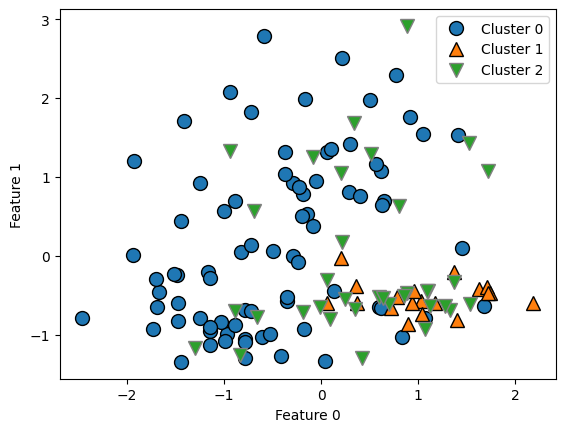

In [8]:
# instantiate an instance of k-Means
kmeans = KMeans(n_clusters=3)
# fit the model to the training data
kmeans.fit(X_train)
# get assignments (labels)
assignments=kmeans.labels_
# plot a scatter matrix of the results
mglearn.discrete_scatter(X_train_scaled[:, 0], X_train_scaled[:, 1], assignments)
plt.legend(["Cluster 0", "Cluster 1", "Cluster 2"], loc="best")
plt.xlabel("Feature 0")
plt.ylabel("Feature 1")

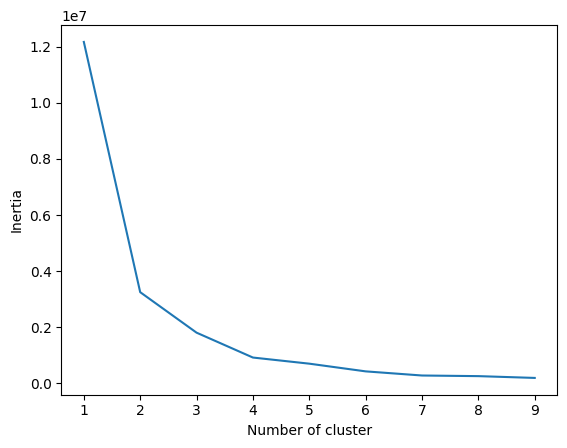

In [9]:
# elbow visualization
inertiaVals = {}

for k in range(1, 10):
    kmeansTmp = KMeans(n_clusters=k, max_iter=1000).fit(X_train)
    inertiaVals[k] = kmeansTmp.inertia_
plt.figure()
plt.plot(list(inertiaVals.keys()), list(inertiaVals.values()))
plt.xlabel("Number of cluster")
plt.ylabel("Inertia")
plt.show()

## Run on data after PCA

Text(0, 0.5, 'Feature 1')

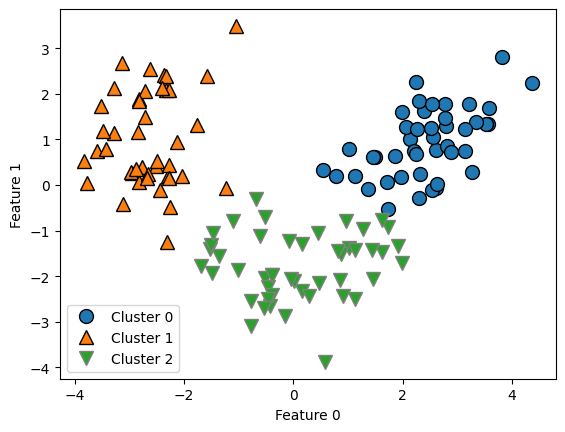

In [10]:
# instantiate an instance of k-Means
kmeans = KMeans(n_clusters=3)
# fit the model to the training data
kmeans.fit(X_train_pca)
# get assignments (labels)
assignments=kmeans.labels_
# plot a scatter matrix of the results
mglearn.discrete_scatter(X_train_pca[:, 0], X_train_pca[:, 1], assignments)
plt.legend(["Cluster 0", "Cluster 1", "Cluster 2"], loc="best")
plt.xlabel("Feature 0")
plt.ylabel("Feature 1")

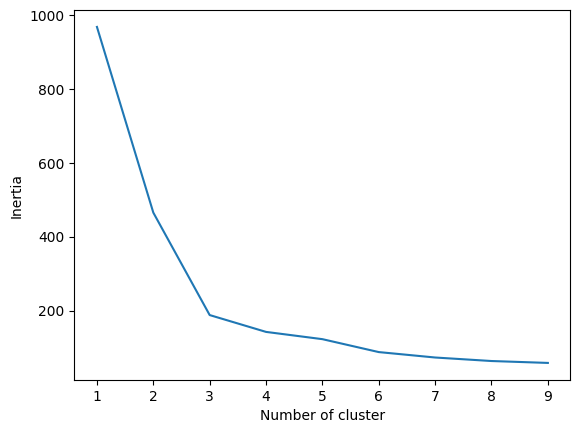

In [12]:
# elbow visualization
inertiaVals = {}

for k in range(1, 10):
    kmeansTmp = KMeans(n_clusters=k, max_iter=1000).fit(X_train_pca)
    inertiaVals[k] = kmeansTmp.inertia_
plt.figure()
plt.plot(list(inertiaVals.keys()), list(inertiaVals.values()))
plt.xlabel("Number of cluster")
plt.ylabel("Inertia")
plt.show()

# Aggolmerate/Hierarchical

In [16]:
# import library
from sklearn.cluster import AgglomerativeClustering

## Run on original data

Text(0, 0.5, 'Feature 1')

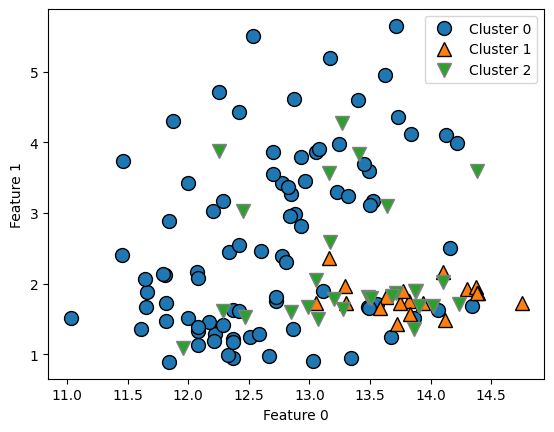

In [20]:
# instantiate an instance of the algorithm
agg = AgglomerativeClustering(n_clusters=3)
# fit the model to the training data
assignment = agg.fit_predict(X_train)
# plot the cluster assignments
mglearn.discrete_scatter(X_train[:, 0], X_train[:, 1], assignment)
plt.legend(["Cluster 0", "Cluster 1", "Cluster 2"], loc="best")
plt.xlabel("Feature 0")
plt.ylabel("Feature 1")

## Run on data after PCA

Text(0, 0.5, 'Feature 1')

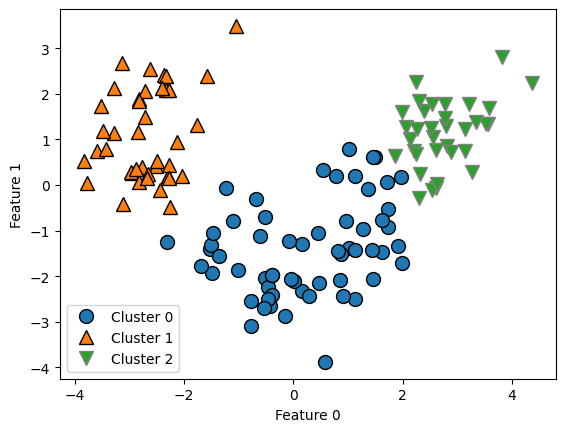

In [19]:
# instantiate an instance of the algorithm
agg = AgglomerativeClustering(n_clusters=3)
# fit the model to the training data
assignment = agg.fit_predict(X_train_pca)
# plot the cluster assignments
mglearn.discrete_scatter(X_train_pca[:, 0], X_train_pca[:, 1], assignment)
plt.legend(["Cluster 0", "Cluster 1", "Cluster 2"], loc="best")
plt.xlabel("Feature 0")
plt.ylabel("Feature 1")

# DBSCAN

In [25]:
# import the library
from sklearn.cluster import DBSCAN

## Run on original data

Text(0, 0.5, 'Feature 1')

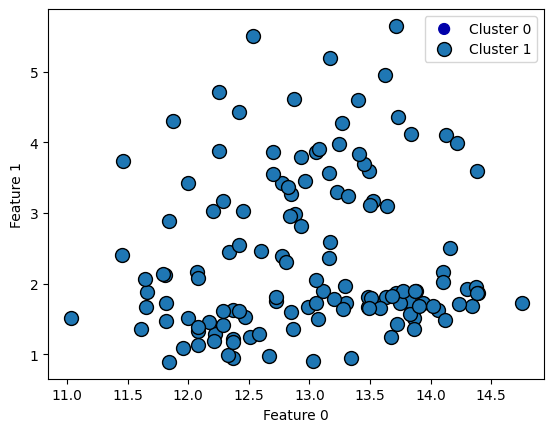

In [33]:
# instantiate an instance of the algorithm
dbscan = DBSCAN(min_samples=50,eps=0.5)
clusters = dbscan.fit_predict(X_train)
# plot the cluster assignments
plt.scatter(X_train[:, 0], X_train[:, 1], c=clusters, cmap=mglearn.cm2, s=60)
plt.xlabel("Feature 0")
plt.ylabel("Feature 1")

mglearn.discrete_scatter(X_train[:, 0], X_train[:, 1], clusters)
plt.legend(["Cluster 0", "Cluster 1", "Cluster 2", "Cluster 3", "Cluster 4"], loc="best")
plt.xlabel("Feature 0")
plt.ylabel("Feature 1")

## Run on data after PCA

Text(0, 0.5, 'Feature 1')

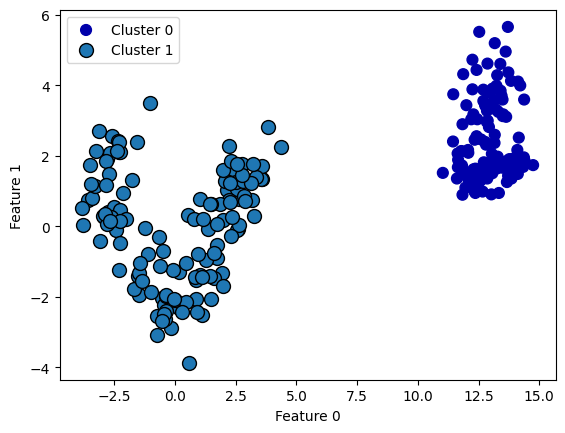

In [32]:
# instantiate an instance of the algorithm
dbscan = DBSCAN(min_samples=50,eps=0.5)
clusters = dbscan.fit_predict(X_train_pca)
# plot the cluster assignments
plt.scatter(X_train[:, 0], X_train[:, 1], c=clusters, cmap=mglearn.cm2, s=60)
plt.xlabel("Feature 0")
plt.ylabel("Feature 1")

mglearn.discrete_scatter(X_train_pca[:, 0], X_train_pca[:, 1], clusters)
plt.legend(["Cluster 0", "Cluster 1", "Cluster 2", "Cluster 3", "Cluster 4"], loc="best")
plt.xlabel("Feature 0")
plt.ylabel("Feature 1")


# Calculate ARI and Silhouette Coefficient

## ARI - Original Data

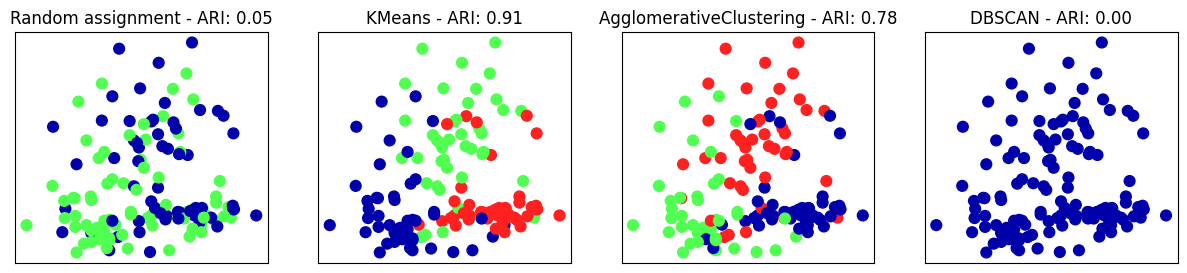

In [35]:
# import library
from sklearn.metrics import adjusted_rand_score
import matplotlib.pyplot as plt
# create subplot
fig, axes = plt.subplots(1, 4, figsize=(15, 3),
                         subplot_kw={'xticks': (), 'yticks': ()})
# make a list of algorithms to use
algorithms = [KMeans(n_clusters=3), AgglomerativeClustering(n_clusters=3),
              DBSCAN()]
# create a random cluster assignment for reference
random_state = np.random.RandomState(seed=0)
random_clusters = random_state.randint(low=0, high=2, size=len(X_train))
# plot random assignment
axes[0].scatter(X_train_scaled[:, 0], X_train_scaled[:, 1], c=random_clusters,
                cmap=mglearn.cm3, s=60)
axes[0].set_title("Random assignment - ARI: {:.2f}".format(
        adjusted_rand_score(y_train, random_clusters)))

for ax, algorithm in zip(axes[1:], algorithms):
    # plot the cluster assignments and cluster centers
    clusters = algorithm.fit_predict(X_train_scaled)
    ax.scatter(X_train_scaled[:, 0], X_train_scaled[:, 1], c=clusters,
               cmap=mglearn.cm3, s=60)
    ax.set_title("{} - ARI: {:.2f}".format(algorithm.__class__.__name__,
                                           adjusted_rand_score(y_train, clusters)))

## ARI - PCA Data

In [ ]:
# create subplot

# make a list of algorithms to use

# create a random cluster assignment for reference

# plot random assignment


## Silhouette Coefficient - Original Data

In [ ]:
# import library

# create subplot

# create a random cluster assignment for reference

# plot random assignment


## Silhouette Coefficient - PCA

In [ ]:
# create subplot

# create a random cluster assignment for reference

# plot random assignment
